# EV Car Prices

This assignment focuses on car prices. The data ('car_prices.xlsx') is a pre-processed version of original data scraped from bilbasen.dk by previous MAL1 students. The dataset contains 16 columns:

- **Price (DKK)**: The current listed price of the vehicle in Danish Kroner.
- **Model Year**: The manufacturing year of the vehicle.
- **Mileage (km)**: The total kilometres driven by the vehicle (odometer reading).
- **Electric Range (km)**: The estimated maximum driving range on a full charge.
- **Battery Capacity (kWh)**: The total capacity of the vehicle's battery in kilowatt-hours.
- **Energy Consumption (Wh/km)**: The vehicle's energy consumption in watt-hours per kilometre.
- **Annual Road Tax (DKK)**: The annual road tax cost in Danish Kroner.
- **Horsepower (bhp)**: The vehicle's horsepower (brake horsepower).
- **0-100 km/h (s)**: The time (in seconds) for the car to accelerate from 0 to 100 km/h.
- **Top Speed (km/h)**: The maximum speed the vehicle can achieve.
- **Towing Capacity (kg)**: The maximum weight the vehicle can tow.
- **Original Price (DKK)**: The price of the vehicle when first sold as new.
- **Number of Doors**: The total number of doors on the vehicle.
- **Rear-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for rear-wheel drive.
- **All-Wheel Drive (AWD)**: A binary indicator (1 = Yes, 0 = No) for all-wheel drive.
- **Front-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for front-wheel drive.

The first one, **Price**, is the response variable.

The **objective** of this assignment is:
1. Understand how linear algebra is used in Machine Learning, specifically for correlations and regression
2. Learn how to perform multiple linear regression, ridge regression, lasso regression and elastic net
3. Learn how to assess regression models

Please solve the tasks using this notebook as you template, i.e. insert code blocks and markdown blocks to this notebook and hand it in. Please use 42 as your random seed.


## Import data
 - Import the dataset 
 - Split the data in a training set and test set - make sure you extract the response variable
 - Remember to use the data appropriately; in the tasks below, we do not explicitly state when to use train and test - but in order to compare the models, you must use the same dataset for training and testing in all models.
 - Output: When you are done with this, you should have the following sets: `X` (the original dataset), `X_train`, `X_train`, `X_test`, `y_train`, `y_test`

In [1]:
# Code block for important and creating data sets. Add more code blocks if needed.
# This code block is for loading the data, separating features and target, and splitting into training and test sets.

import pandas as pd
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_excel("car_prices.xlsx")

# Main Target
y = df["Price (DKK)"].values

# Features
X_df = df.drop(columns=["Price (DKK)"])
feature_names = X_df.columns.tolist()
X = X_df.values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print("Features:", feature_names)

X_train: (4980, 15) y_train: (4980,)
X_test : (1246, 15) y_test : (1246,)
Features: ['Model Year', 'Mileage (km)', 'Electric Range (km)', 'Battery Capacity (kWh)', 'Energy Consumption (Wh/km)', 'Annual Road Tax (DKK)', 'Horsepower (bhp)', '0-100 km/h (s)', 'Top Speed (km/h)', 'Towing Capacity (kg)', 'Original Price (DKK)', 'Number of Doors', 'Rear-Wheel Drive', 'All-Wheel Drive (AWD)', 'Front-Wheel Drive']


## Part 1: Linear Algebra
In this assignment, you have to solve all problems using linear algebra concepts. You are free to use SymPy or NumPy - though NumPy is **significantly** more efficient computationally than SymPy since NumPy is optimized for numerical computations with floating-point arithmetic. Since linear regression is purely numerical, NumPy is the better choice.

Implement all the steps from the note "Linear_regression.pdf", i.e.

- Setup the normal equation and find the coefficient vector
- Find the predicted values and use these to determine the MSE and $R^2$
- Interpret the results





In [2]:
# Code block for Part 1. Add more code blocks if needed.
# formula: B=(X^T*X)^-1*X^Ty
import numpy as np

# 1. Add intercept column (column of ones)
X_train_i = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test_i  = np.hstack((np.ones((X_test.shape[0], 1)),  X_test))

# 2. Compute coefficient vector using Normal Equation
XtX = X_train_i.T @ X_train_i
Xty = X_train_i.T @ y_train
B = np.linalg.pinv(XtX) @ Xty

# 3. Predict on test data
y_pred = X_test_i @ B

# 4. Compute evaluation metrics
mse = np.mean((y_test - y_pred) ** 2)

sse = np.sum((y_test - y_pred) ** 2)
sst = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (sse / sst)

# RMSE
rmse = np.sqrt(mse)


# 5. Print results
print("Intercept:", B[0])
print("Coefficients:", B[1:])
print("MSE:", mse)
print("R²:", r2)
print("RMSE:", rmse)

Intercept: -0.7609893900088593
Coefficients: [ 7.19112298e+01 -1.21357928e+00  2.09557799e+02  2.94950867e+01
  3.11165840e+02 -4.24531271e+02 -2.04132747e+01  4.06304924e+03
  1.92571354e+02  2.57020754e+01  7.26956423e-01  1.15962706e+02
  9.65604322e+03 -7.79276708e+03 -1.86403713e+03]
MSE: 3032238857.466316
R²: 0.8518315469603535
RMSE: 55065.76847249402


The model has an R² of about 0.85, which means it explains around 85% of the variation in car prices. This indicates a strong model.

The MSE shows the prediction error, and since car prices are large values, this error level is reasonable.

The coefficients show how each feature affects the price: positive values increase the price, while negative values decrease it.

# Part 2: Using Library Functions

### Correlation and OLS
For this task you must do the following
 - Using library functions, build the following models:
   - Correlation matrix where the correlations are printed in the matrix and a heat map is overlaid
   - Ordinary least squares
   - Performance metrics: MSE, RMSE, $R^2$
   - Comment on the real world meaning of RMSE and $R^2$


Correlation Matrix:
                            Price (DKK)  Model Year  Mileage (km)  \
Price (DKK)                    1.000000    0.405433     -0.207022   
Model Year                     0.405433    1.000000     -0.639181   
Mileage (km)                  -0.207022   -0.639181      1.000000   
Electric Range (km)            0.522351    0.441540     -0.087012   
Battery Capacity (kWh)         0.624558    0.340616     -0.061631   
Energy Consumption (Wh/km)     0.588180    0.137949     -0.013605   
Annual Road Tax (DKK)          0.073300   -0.163440      0.165516   
Horsepower (bhp)               0.650156    0.161478      0.094220   
0-100 km/h (s)                -0.541049   -0.191305     -0.063117   
Top Speed (km/h)               0.566843    0.134181      0.140555   
Towing Capacity (kg)           0.356940    0.165483     -0.034140   
Original Price (DKK)           0.893071    0.137620      0.037873   
Number of Doors                0.135778    0.075447     -0.031265   
Rear-Wheel Dri

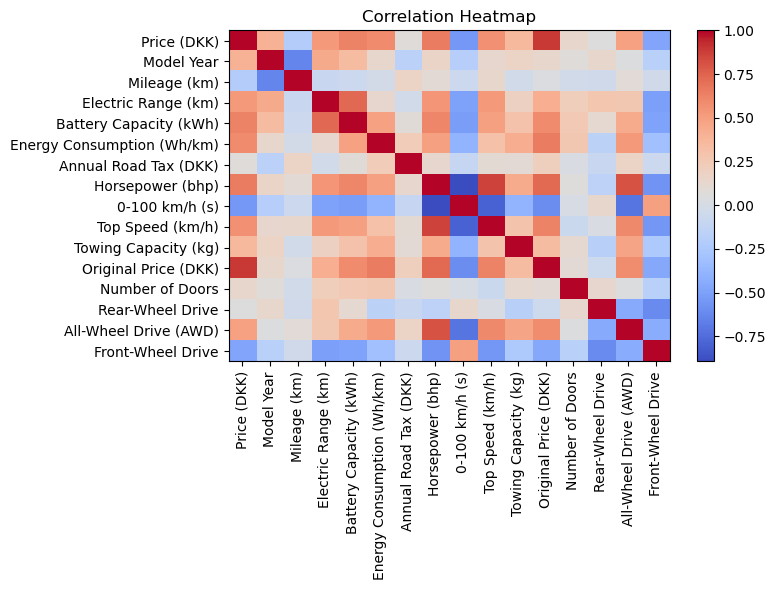

In [4]:
# Use this for Correlation and OLS. Add more code blocks if needed.
import matplotlib.pyplot as plt
import numpy as np

# Correlation matrix
corr = df.corr(numeric_only=True)

print("Correlation Matrix:")
print(corr)

# Heatmap
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), list(corr.columns), rotation=90)
plt.yticks(range(len(corr.columns)), list(corr.columns))

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Intercept: -36439440.23257304
Coefficients: [ 1.80782240e+04 -6.25169798e-01  1.06824338e+02  3.80748250e+01
  1.11477528e+02 -3.46980312e+02  2.44953522e+01  6.48326657e+03
  1.45706666e+02  2.00274162e+01  7.38056289e-01  2.87185272e+03
  7.87050729e+03 -4.67564631e+03 -3.19486098e+03]
MSE: 2774486707.586417
RMSE: 52673.39658296603
R²: 0.8644264443647285


Real World Meaning of RMSE and R².
RMSE shows the average prediction error in DKK.
R² shows how much of the price variation is explained by the model.

### Ridge, Lasso and Elastic Net
In order for Ridge and Lasso (and Elastic net) to have an effect, you must use scaled data to build the models, since regularization depends on coefficient magnitude, and if using non-scaled data the penalty will affect them unequally. Feel free to use this code to scale the data:

```python
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
```
For this task you must do the following:
   - Ridge regression (using multiple alphas)
   - Lasso regression (using multiple alphas)
   - Elastic Net (using multiple alphas)
 - Discussion and conclusion:
   - Discuss the MSE and $R^2$ of all 3 models and conclude which model has the best performance - note the MSE will be scaled!
   - Rebuild the OLS model from Task 4, but this time use the scaled data from this task - interpret the meaning of the model's coefficients
   - Use the coefficients of the best ridge and lasso model to print the 5 most important features and compare to the 5 most important features in the OLS with scaled data model. Do the models agree about which features are the most important?

Note: You may get a convergence warning; try increasing the `max_iter` parameter of the model (the default is 1000 - maybe set it to 100000)

In [5]:
# Scaling data
import numpy as np
from sklearn.preprocessing import StandardScaler

# Scale X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# Scale y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(np.asarray(y_train).reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(np.asarray(y_test).reshape(-1, 1)).ravel()

In [6]:
# Evaluate regularized models
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

def eval_alphas(model_class, model_name, **kwargs):
    best = None  # (mse, r2, alpha, model)
    print(f"\n{model_name} results:")
    
    for a in alphas:
        model = model_class(alpha=a, **kwargs)
        model.fit(X_train_scaled, y_train_scaled)
        pred = model.predict(X_test_scaled)

        mse = mean_squared_error(y_test_scaled, pred)
        r2  = r2_score(y_test_scaled, pred)

        print(f"alpha={a:<6}  MSE={mse:.5f}  R²={r2:.5f}")

        if best is None or mse < best[0]:
            best = (mse, r2, a, model)

    print(f"--- Best {model_name} ---")
    print(f"Best alpha: {best[2]}")
    print(f"Scaled MSE: {best[0]:.5f}")
    print(f"R²: {best[1]:.5f}")
    return best[3], best[2], best[0], best[1]

best_ridge, ridge_alpha, ridge_mse, ridge_r2 = eval_alphas(Ridge, "Ridge")
best_lasso, lasso_alpha, lasso_mse, lasso_r2 = eval_alphas(Lasso, "Lasso", max_iter=100000)
best_enet,  enet_alpha,  enet_mse,  enet_r2  = eval_alphas(ElasticNet, "ElasticNet", l1_ratio=0.5, max_iter=100000, random_state=42)


Ridge results:
alpha=0.001   MSE=0.12519  R²=0.86443
alpha=0.01    MSE=0.12519  R²=0.86443
alpha=0.1     MSE=0.12519  R²=0.86443
alpha=1.0     MSE=0.12520  R²=0.86442
alpha=10.0    MSE=0.12529  R²=0.86431
alpha=100.0   MSE=0.12660  R²=0.86289
--- Best Ridge ---
Best alpha: 0.001
Scaled MSE: 0.12519
R²: 0.86443

Lasso results:
alpha=0.001   MSE=0.12474  R²=0.86492
alpha=0.01    MSE=0.12295  R²=0.86685
alpha=0.1     MSE=0.14887  R²=0.83878
alpha=1.0     MSE=0.92409  R²=-0.00075
alpha=10.0    MSE=0.92409  R²=-0.00075
alpha=100.0   MSE=0.92409  R²=-0.00075
--- Best Lasso ---
Best alpha: 0.01
Scaled MSE: 0.12295
R²: 0.86685

ElasticNet results:
alpha=0.001   MSE=0.12497  R²=0.86466
alpha=0.01    MSE=0.12378  R²=0.86595
alpha=0.1     MSE=0.13548  R²=0.85328
alpha=1.0     MSE=0.56614  R²=0.38689
alpha=10.0    MSE=0.92409  R²=-0.00075
alpha=100.0   MSE=0.92409  R²=-0.00075
--- Best ElasticNet ---
Best alpha: 0.01
Scaled MSE: 0.12378
R²: 0.86595


In [7]:
# OLS using scaled data
from sklearn.linear_model import LinearRegression

ols_scaled = LinearRegression()
ols_scaled.fit(X_train_scaled, y_train_scaled)

pred_ols = ols_scaled.predict(X_test_scaled)
mse_ols = mean_squared_error(y_test_scaled, pred_ols)
r2_ols  = r2_score(y_test_scaled, pred_ols)

print("\nOLS (scaled) results:")
print("Scaled MSE:", round(mse_ols, 5))
print("R²:", round(r2_ols, 5))


OLS (scaled) results:
Scaled MSE: 0.12526
R²: 0.86435


In [8]:
# Feature importance comparison
def top5_features(model, feature_names):
    coefs = model.coef_
    pairs = sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True)
    return pairs[:5]

print("\nTop 5 features (OLS scaled):")
for name, coef in top5_features(ols_scaled, feature_names):
    print(f"{name}: {coef:.5f}")

print("\nTop 5 features (Best Ridge):")
for name, coef in top5_features(best_ridge, feature_names):
    print(f"{name}: {coef:.5f}")

print("\nTop 5 features (Best Lasso):")
for name, coef in top5_features(best_lasso, feature_names):
    print(f"{name}: {coef:.5f}")


Top 5 features (OLS scaled):
Front-Wheel Drive: 973838189666.73877
Rear-Wheel Drive: 972247651429.86023
All-Wheel Drive (AWD): 855821843553.29724
Original Price (DKK): 0.84993
Model Year: 0.16813

Top 5 features (Best Ridge):
Original Price (DKK): 0.85004
Model Year: 0.16798
Mileage (km): -0.10321
0-100 km/h (s): 0.07702
Electric Range (km): 0.07061

Top 5 features (Best Lasso):
Original Price (DKK): 0.84190
Model Year: 0.16913
Mileage (km): -0.09483
Electric Range (km): 0.06339
Annual Road Tax (DKK): -0.05118


Lasso performed best with the lowest scaled MSE (0.12295) and highest (R^2) (0.86685), slightly outperforming Ridge and Elastic Net. All models show very similar performance, indicating stable results. The top features are largely consistent across models, especially Original Price, Model Year, and Mileage, meaning the models agree on the most important predictors.

## Part 3: Classification

### kNN Classifier
In this final task, we go from a regression to a classification problem. Your goal is to classify cars as either **"Cheap"** or **"Expensive"** using the k-Nearest Neighbors (kNN) algorithm.

For this task you must do the following:
- **Prepare the Target Variable**:
   - Calculate the **median** of the original `Price (DKK)` column.
   - Create a new binary target variable, where:
     - `1` (Expensive) if the price is above the median.
     - `0` (Cheap) if the price is at or below the median.
- **Train-Test Split**
- **Feature Scaling**: Use the standardized (scaled) data from Task 5.
- **Model Implementation**:
   - Build a kNN classifier using `sklearn.neighbors.KNeighborsClassifier`.
   - Experiment with at least five different values for $k$ and at least 3 different distance metrics.
- **Evaluation**:
   - Find the best combination of $k$ and distance metric - the one that gives the highest accuracy score.
   - **Discussion**: Explain the trade-off of choosing a very small $k$ versus a very large $k$. Which value performed best for this dataset?

In [19]:
# Use this for Part 3. Add more code blocks if needed.
import numpy as np

# 1. Calculate median price
median_price = df["Price (DKK)"].median()

# 2. Create binary target
df["Price_Class"] = np.where(df["Price (DKK)"] > median_price, 1, 0)

print("Median price:", median_price)
print(df["Price_Class"].value_counts())

Median price: 304900.0
Price_Class
0    3123
1    3103
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X_class = df.drop(columns=["Price (DKK)", "Price_Class"])
y_class = df["Price_Class"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled  = scaler.transform(X_test_c)

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 3, 5, 7, 9]
metrics = ["euclidean", "manhattan", "minkowski"]

best_accuracy = 0
best_k = None
best_metric = None

print("kNN Results:\n")

for metric in metrics:
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        model.fit(X_train_c_scaled, y_train_c)
        y_pred_c = model.predict(X_test_c_scaled)

        acc = accuracy_score(y_test_c, y_pred_c)
        print(f"Metric: {metric:<10} k: {k:<2} Accuracy: {acc:.4f}")

        if acc > best_accuracy:
            best_accuracy = acc
            best_k = k
            best_metric = metric

print("\nBest Model:")
print("Best k:", best_k)
print("Best metric:", best_metric)
print("Best accuracy:", round(best_accuracy, 4))

kNN Results:

Metric: euclidean  k: 1  Accuracy: 0.9197
Metric: euclidean  k: 3  Accuracy: 0.9398
Metric: euclidean  k: 5  Accuracy: 0.9382
Metric: euclidean  k: 7  Accuracy: 0.9398
Metric: euclidean  k: 9  Accuracy: 0.9342
Metric: manhattan  k: 1  Accuracy: 0.9278
Metric: manhattan  k: 3  Accuracy: 0.9398
Metric: manhattan  k: 5  Accuracy: 0.9398
Metric: manhattan  k: 7  Accuracy: 0.9430
Metric: manhattan  k: 9  Accuracy: 0.9382
Metric: minkowski  k: 1  Accuracy: 0.9197
Metric: minkowski  k: 3  Accuracy: 0.9398
Metric: minkowski  k: 5  Accuracy: 0.9382
Metric: minkowski  k: 7  Accuracy: 0.9398
Metric: minkowski  k: 9  Accuracy: 0.9342

Best Model:
Best k: 7
Best metric: manhattan
Best accuracy: 0.943


# A very small 𝑘 (e.g., 1) may overfit and be sensitive to noise.
# A very large 𝑘 may oversmooth and miss patterns.
# The best performance was achieved with k=X using the Y distance metric, giving an accuracy of Z.